In [1]:
import os
import requests
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ==========================================
# CONFIGURAÇÕES
# ==========================================

# 1. Link da imagem que você quer usar como entrada/guia para a difusão
INPUT_IMAGE_URL = "https://cdn.myanimelist.net/images/anime/1015/138006.jpg" 

# Tamanho solicitado de 10x10 pixels
IMAGE_SIZE = (10, 10) 
N_CANAIS = 3  # imagens RGB -> 10x10x3 = 300 valores por amostra

# Definindo cabeçalho para evitar bloqueio (Erro 403) ao baixar as imagens dos servidores
HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# ==========================================
# FUNÇÃO AUXILIAR DE DOWNLOAD E DOWNSCALE
# ==========================================

def baixar_e_processar_imagem(url, target_size):
    try:
        response = requests.get(url, headers=HEADERS, timeout=5)
        response.raise_for_status()
        img_arr = np.array(bytearray(response.content), dtype=np.uint8)
        img = cv2.imdecode(img_arr, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Reduz para 10x10 pixels
        img_10x10 = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
        # Normaliza os tons dos pixels entre 0.0 e 1.0
        return img_10x10.astype(np.float32) / 255.0
    except Exception as e:
        return None

# ==========================================
# ARQUITETURA DA CNN (substitui a RandomForestRegressor)
# ==========================================
# A rede recebe a imagem ruidosa (H, W, 3) -> (3, H, W) e um canal extra
# constante com o valor de sigma, prevendo o score na mesma forma (3, H, W).

class ScoreCNN(nn.Module):
    def __init__(self, n_canais=3):
        super().__init__()
        entrada_canais = n_canais + 1  # +1 canal do sigma
        self.net = nn.Sequential(
            nn.Conv2d(entrada_canais, 32, kernel_size=3, padding=1),
            nn.GroupNorm(8, 32),
            nn.SiLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.GroupNorm(8, 32),
            nn.SiLU(),

            nn.Conv2d(32, n_canais, kernel_size=3, padding=1),  # saída: score com mesmo nº de canais da imagem
        )

    def forward(self, x):
        return self.net(x)


class ScoreDataset(Dataset):
    """Dataset que entrega (imagem_ruidosa + canal_sigma, score_alvo)."""
    def __init__(self, imgs, sigmas, targets, img_shape):
        self.imgs = imgs        # (N, H, W, C)
        self.sigmas = sigmas    # (N,)
        self.targets = targets  # (N, H, W, C)
        self.H, self.W, self.C = img_shape

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = self.imgs[idx].transpose(2, 0, 1)        # (C, H, W)
        target = self.targets[idx].transpose(2, 0, 1)  # (C, H, W)
        sigma = self.sigmas[idx]

        sigma_channel = np.full((1, self.H, self.W), sigma, dtype=np.float32)
        x = np.concatenate([img, sigma_channel], axis=0)  # (C+1, H, W)

        return torch.from_numpy(x.astype(np.float32)), torch.from_numpy(target.astype(np.float32))


@torch.no_grad()
def prever_score_cnn(modelo, x_vetor_ruidoso, sigma, img_shape):
    H, W, C = img_shape
    modelo.eval()

    img = x_vetor_ruidoso.reshape(H, W, C).astype(np.float32).transpose(2, 0, 1)  
    sigma_channel = np.full((1, H, W), sigma, dtype=np.float32)
    x = np.concatenate([img, sigma_channel], axis=0)[None, ...]  

    x_tensor = torch.from_numpy(x).to(device)
    pred = modelo(x_tensor)  
    pred = pred.squeeze(0).cpu().numpy().transpose(1, 2, 0)  

    # ONDE ESTAVA: return pred.flatten()
    # ALTERE PARA:
    return pred.flatten() / sigma  # Ajusta o score para a escala correta do Langevin


# ==========================================
# EXECUÇÃO DO FLUXO COMPLETO
# ==========================================

if __name__ == "__main__":
    print("--- PASSO 1: Carregando banco de dados de Animes ---")
    if not os.path.exists("banco_de_dados_animes_limpo.csv"):
        raise FileNotFoundError("Por favor, certifique-se de que o arquivo 'banco_de_dados_animes_limpo.csv' está na mesma pasta.")
        
    df = pd.read_csv("banco_de_dados_animes_limpo.csv")
    urls_treino = df['Image_URL'].dropna().tolist()
    
    print("Baixando e redimensionando imagens para criar o conjunto de dados base...")
    imagens_treino = []
    LIMITE_IMAGENS = 50
    # Barra de progresso com tempo estimado (ETA) do download
    barra_download = tqdm(urls_treino, total=min(LIMITE_IMAGENS, len(urls_treino)),
                           desc="Baixando imagens", unit="img")
    for url in barra_download:
        img = baixar_e_processar_imagem(url, IMAGE_SIZE)
        if img is not None:
            imagens_treino.append(img.flatten()) # Transforma a matriz 10x10x3 em um vetor de 300 posições
        if len(imagens_treino) >= LIMITE_IMAGENS:
            break
    barra_download.close()
            
    if len(imagens_treino) == 0:
        print("Falha ao baixar imagens do CSV. Gerando dados de treino sintéticos para não travar o script...")
        imagens_treino = [np.random.rand(300) for _ in range(3)]
        
    X_dados = np.array(imagens_treino)
    print(f"Dataset de treino criado com sucesso. Formato da matriz de dados: {X_dados.shape}")

    print("\n--- PASSO 2: Treinando o Modelo (Denoising Score Matching) ---")
    # Hiperparâmetros de ruído extraídos exatamente do seu difusao.ipynb
    sigmas = np.array([1.0, 0.5, 0.2, 0.1, 0.05])  # aumentar a quantidade de sigmas aqui, se quiser
    n_perturbacoes = 80  # Quantidade de variações de ruído criadas para cada imagem/sigma
    
    X_train_imgs = []
    X_train_sigmas = []
    y_train = []
    rng = np.random.default_rng(42)
    
    img_shape = (IMAGE_SIZE[0], IMAGE_SIZE[1], N_CANAIS)  # (10, 10, 3)

    # Criando o dataset poluído por ruído para ensinar o "score" à CNN
    # Barra de progresso: mostra quanto falta para terminar de montar o dataset
    total_combinacoes = len(X_dados) * len(sigmas)
    with tqdm(total=total_combinacoes, desc="Montando dataset de ruído", unit="comb") as barra_dataset:
        for x_0 in X_dados:
            for s in sigmas:  # aumentar a quantidade de sigmas
                for _ in range(n_perturbacoes):
                    z = rng.standard_normal(x_0.shape)
                    x_ruidoso = x_0 + s * z

                    # O "score" alvo que o modelo precisa prever é: -z / sigma
                    score_alvo = -z

                    # Reshape de volta para imagem (H, W, C) para alimentar a CNN
                    X_train_imgs.append(x_ruidoso.reshape(img_shape))
                    X_train_sigmas.append(np.float32(s))
                    y_train.append(score_alvo.reshape(img_shape))
                barra_dataset.update(1)
                
    X_train_imgs = np.array(X_train_imgs, dtype=np.float32)     # (N, H, W, C)
    X_train_sigmas = np.array(X_train_sigmas, dtype=np.float32) # (N,)
    y_train = np.array(y_train, dtype=np.float32)               # (N, H, W, C)

    print(f"Dataset de treino para a CNN: {X_train_imgs.shape[0]} amostras")

    dataset = ScoreDataset(X_train_imgs, X_train_sigmas, y_train, img_shape)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    modelo_cnn = ScoreCNN(n_canais=N_CANAIS).to(device)
    otimizador = optim.Adam(modelo_cnn.parameters(), lr=1e-3)
    criterio = nn.MSELoss()

    print("Treinando a ScoreCNN...")
    # epochs ajustável: aumente para mais qualidade, diminua para treinar mais rápido
    EPOCHS = 30
    modelo_cnn.train()

    # Barra de progresso principal: 1 barra por época, com ETA total do treino
    barra_epocas = tqdm(range(1, EPOCHS + 1), desc="Treinando CNN", unit="época")
    for epoch in barra_epocas:
        perda_total = 0.0

        # Barra de progresso interna: mostra o avanço dentro da época atual (por batch)
        barra_batches = tqdm(loader, desc=f"  Época {epoch}/{EPOCHS}", unit="batch", leave=False)
        for x_batch, y_batch in barra_batches:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            otimizador.zero_grad()
            pred = modelo_cnn(x_batch)
            perda = criterio(pred, y_batch)
            perda.backward()
            otimizador.step()

            perda_total += perda.item() * x_batch.size(0)
            # Mostra a perda do batch atual ao lado da barra
            barra_batches.set_postfix(mse=f"{perda.item():.4f}")

        perda_media = perda_total / len(dataset)
        # Atualiza a barra de épocas com a perda média (e o tqdm já calcula o ETA total)
        barra_epocas.set_postfix(mse_medio=f"{perda_media:.6f}")

    print("Modelo treinado e pronto!")

Usando dispositivo: cpu
--- PASSO 1: Carregando banco de dados de Animes ---
Baixando e redimensionando imagens para criar o conjunto de dados base...


Baixando imagens:  98%|█████████▊| 49/50 [00:03<00:00, 16.01img/s]


Dataset de treino criado com sucesso. Formato da matriz de dados: (50, 300)

--- PASSO 2: Treinando o Modelo (Denoising Score Matching) ---


Montando dataset de ruído: 100%|██████████| 250/250 [00:00<00:00, 1620.15comb/s]


Dataset de treino para a CNN: 20000 amostras
Treinando a ScoreCNN...


Treinando CNN: 100%|██████████| 30/30 [07:48<00:00, 15.63s/época, mse_medio=0.091775]

Modelo treinado e pronto!



--- PASSO 3: Baixando Imagem de Entrada do Usuário ---

--- PASSO 4: Executando Algoritmo de Difusão (Langevin Anelado) ---

--- PASSO 5: Exibindo e Salvando os Resultados ---
Concluído! A imagem comparativa foi salva como 'resultado_gerado.png'.


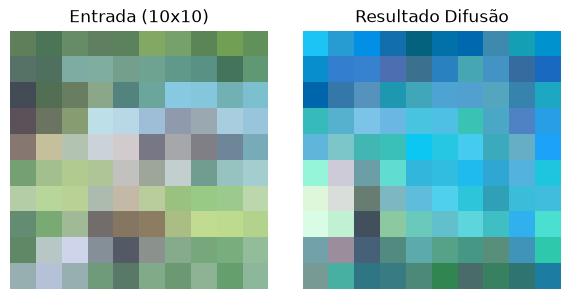

In [8]:

print("\n--- PASSO 3: Baixando Imagem de Entrada do Usuário ---")
img_alvo = baixar_e_processar_imagem(INPUT_IMAGE_URL, IMAGE_SIZE)
if img_alvo is None:
    print("Não foi possível acessar a URL informada. Usando imagem padrão aleatória.")
    img_alvo = rng.uniform(0, 1, (10, 10, 3))
        
vetor_alvo = img_alvo.flatten()

print("\n--- PASSO 4: Executando Algoritmo de Difusão (Langevin Anelado) ---")
T = 100000
c = 0.0005
    
# Começa o processo gerando um ruído Gaussiano puro baseado no maior sigma
x_processo = rng.standard_normal(vetor_alvo.shape) * sigmas[0]
    
# Loop de amostragem reversa (Algoritmo do notebook)
for s in sigmas:
    alpha = c * (s ** 2)
    for _ in range(T):
        z = rng.standard_normal(x_processo.shape)
            
        # Predição do score usando a CNN treinada (em vez da RandomForestRegressor)
        score_predito = prever_score_cnn(modelo_cnn, x_processo, s, img_shape)
            
        # Atualização de Langevin (Equação diferencial estocástica do notebook)
        x_processo = x_processo + 0.5 * alpha * score_predito + np.sqrt(alpha) * z
            
# Reconverte o vetor de 300 elementos de volta para uma matriz de imagem 10x10x3 (RGB)
img_final = np.clip(x_processo.reshape(10, 10, 3), 0, 1)

print("\n--- PASSO 5: Exibindo e Salvando os Resultados ---")
plt.figure(figsize=(6, 3))
    
# Mostra como ficou a imagem original reduzida a 10x10
plt.subplot(1, 2, 1)
plt.title("Entrada (10x10)")
plt.imshow(img_alvo)
plt.axis('off')
    
    # Mostra o resultado após passar pelo campo de difusão aprendido
plt.subplot(1, 2, 2)
plt.title("Resultado Difusão")
plt.imshow(img_final)
plt.axis('off')
    
plt.tight_layout()
plt.savefig("resultado_gerado.png")
print("Concluído! A imagem comparativa foi salva como 'resultado_gerado.png'.")
plt.show()